# Day 13: Student Admission Prediction using Logistic Regression

In this notebook, we will:
1. Load a student admission dataset
2. Perform Exploratory Data Analysis
3. Build a Logistic Regression model using scikit-learn
4. Evaluate the model using different metrics (Accuracy, Precision, Recall, F1 Score)
5. Understand what each evaluation metric means and when to use it

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('student_admission.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (50, 6)


,GPA,GRE_Score,Research_Papers,Extracurriculars,Hours_Studied,Admitted
0,3.9,330,4,3,45,1
1,3.5,310,2,2,35,1
2,2.8,280,0,1,20,0
3,3.7,325,3,4,40,1
4,2.5,260,0,0,15,0


In [3]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GPA               50 non-null     float64
 1   GRE_Score         50 non-null     int64  
 2   Research_Papers   50 non-null     int64  
 3   Extracurriculars  50 non-null     int64  
 4   Hours_Studied     50 non-null     int64  
 5   Admitted          50 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 2.5 KB
None


In [4]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,GPA,GRE_Score,Research_Papers,Extracurriculars,Hours_Studied,Admitted
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000
mean,3.182000,296.94000,1.720000,1.760000,27.620000,0.520000
std,0.476676,26.76764,1.773271,1.333401,11.881885,0.504672
min,2.400000,250.00000,0.000000,0.000000,8.000000,0.000000
25%,2.800000,275.25000,0.000000,1.000000,17.250000,0.000000
50%,3.200000,299.00000,1.000000,2.000000,27.500000,1.000000
75%,3.600000,319.50000,3.000000,3.000000,37.750000,1.000000
max,3.900000,340.00000,6.000000,4.000000,48.000000,1.000000


In [5]:
# Check class distribution
print("Class Distribution:")
print(df['Admitted'].value_counts())
print(f"\nAdmitted: {df['Admitted'].sum()} ({df['Admitted'].mean()*100:.1f}%)")
print(f"Not Admitted: {(df['Admitted']==0).sum()} ({(1-df['Admitted'].mean())*100:.1f}%)")

Class Distribution:
Admitted
1    26
0    24
Name: count, dtype: int64

Admitted: 26 (52.0%)
Not Admitted: 24 (48.0%)


## 2.1 Check for Missing and Duplicate Data

In [ ]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

# Check for duplicate rows
print(f"\nNumber of Duplicate Rows: {df.duplicated().sum()}")
print("\nDuplicate Rows:")
df[df.duplicated(keep=False)]

## 2.2 Handle Missing Values

In [ ]:
# Fill missing numerical values with column mean
numerical_cols = ['GPA', 'GRE_Score', 'Research_Papers', 'Extracurriculars', 'Hours_Studied']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill missing target variable with mode
df['Admitted'] = df['Admitted'].fillna(df['Admitted'].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum())
print(f"\nDataset shape: {df.shape}")

## 2.3 Handle Duplicate Data

In [ ]:
print(f"Shape before removing duplicates: {df.shape}")

# Remove duplicate rows, keeping the first occurrence
df = df.drop_duplicates()

print(f"Shape after removing duplicates: {df.shape}")
print(f"Rows removed: {df.shape[0]} remaining")
print(f"\nDuplicate rows remaining: {df.duplicated().sum()}")
df.head()

## 3. Exploratory Data Analysis (EDA)

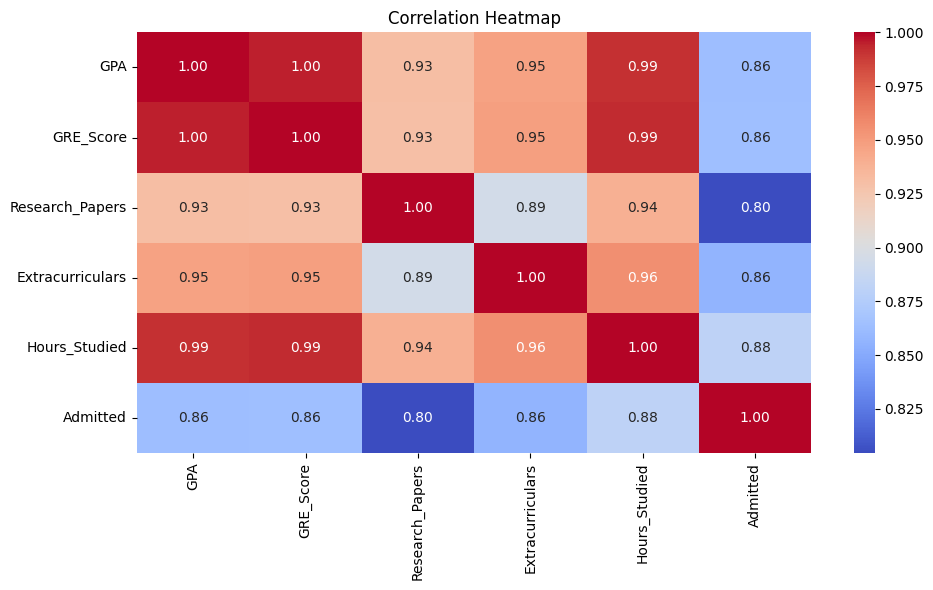

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

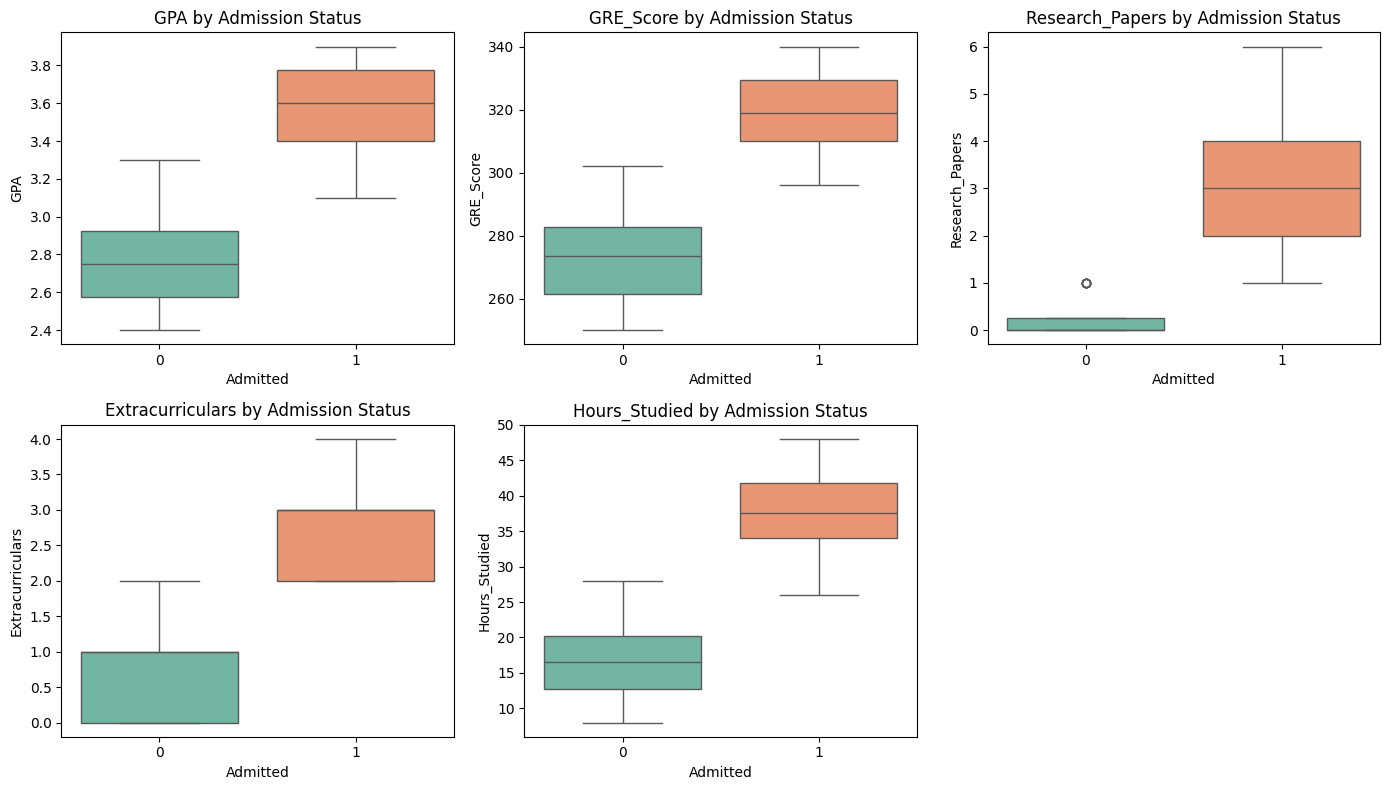

In [7]:
# Distribution of features by admission status
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['GPA', 'GRE_Score', 'Research_Papers', 'Extracurriculars', 'Hours_Studied']

for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    sns.boxplot(x='Admitted', y=feature, data=df, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'{feature} by Admission Status')

# Hide the empty subplot
axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

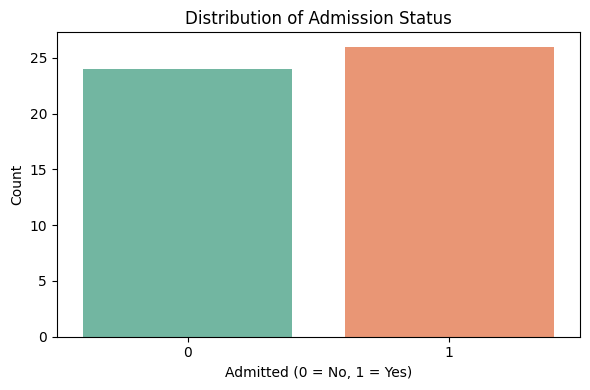

In [8]:
# Count plot of admission status
plt.figure(figsize=(6, 4))
sns.countplot(x='Admitted', data=df, palette='Set2')
plt.title('Distribution of Admission Status')
plt.xlabel('Admitted (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Train-Test Split

In [9]:
# Separate features and target
X = df.drop('Admitted', axis=1)
y = df['Admitted']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Features (X) shape: (50, 5)
Target (y) shape: (50,)

Training set size: 40
Testing set size: 10


## 5. Build Logistic Regression Model

In [10]:
# Create and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Display model parameters
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model.intercept_[0]:.4f}")

Model Coefficients:
  GPA: -0.0597
  GRE_Score: -0.0711
  Research_Papers: 0.1540
  Extracurriculars: 0.3275
  Hours_Studied: 0.7577

Intercept: -0.0049


## 6. Make Predictions

In [11]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_pred_proba.round(4)
})
print("Actual vs Predicted Admission:")
comparison

Actual vs Predicted Admission:


,Actual,Predicted,Probability
0,1,1,0.9649
1,0,0,0.0000
2,1,1,1.0000
3,1,1,0.9891
4,1,1,0.9905
5,0,0,0.0354
6,0,0,0.0004
7,1,1,0.9982
8,1,0,0.4690
9,1,1,0.9999


## 7. Confusion Matrix

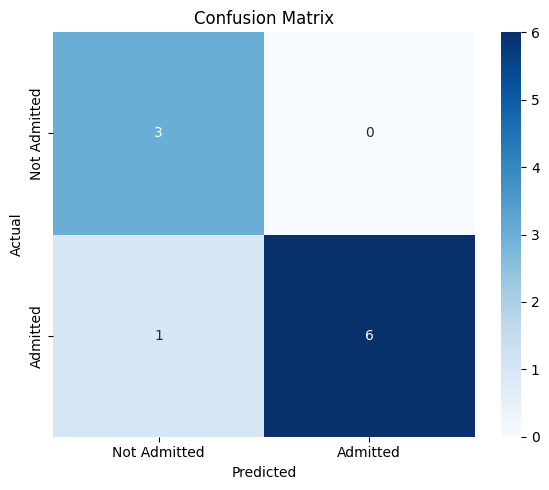


True Negatives (TN): 3
False Positives (FP): 0
False Negatives (FN): 1
True Positives (TP): 6


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Admitted', 'Admitted'],
            yticklabels=['Not Admitted', 'Admitted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (TN): {cm[0][0]}")
print(f"False Positives (FP): {cm[0][1]}")
print(f"False Negatives (FN): {cm[1][0]}")
print(f"True Positives (TP): {cm[1][1]}")

---
## 8. Evaluation Metrics

Now let's evaluate our model using different classification metrics. Each metric tells us something different about our model's performance.

---

### 8.1 Accuracy

**Formula:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**Explanation:**
- Accuracy measures the **proportion of correct predictions** out of all predictions.
- It tells us how often our model is correct overall.
- **Range**: 0 to 1 (or 0% to 100%).
- **Interpretation**: Higher accuracy = Better model. An accuracy of 0.90 means 90% of predictions are correct.
- **Advantage**: Simple and intuitive.
- **Disadvantage**: Misleading for imbalanced datasets (e.g., 95% of one class).

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nInterpretation: Our model correctly predicts admission status {accuracy*100:.2f}% of the time.")

Accuracy: 0.9000

Interpretation: Our model correctly predicts admission status 90.00% of the time.


---

### 8.2 Precision

**Formula:**

$$Precision = \frac{TP}{TP + FP}$$

**Explanation:**
- Precision measures **how many of the predicted positives are actually positive**.
- It answers: "When the model says a student is admitted, how often is it correct?"
- **Range**: 0 to 1.
- **Interpretation**: Higher precision = Fewer false alarms. A precision of 0.85 means 85% of predicted admissions are actual admissions.
- **Advantage**: Important when **false positives are costly** (e.g., spam detection, fraud detection).
- **Disadvantage**: Doesn't account for false negatives (missed positives).

In [14]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"\nInterpretation: When our model predicts 'Admitted', it is correct {precision*100:.2f}% of the time.")
print("High precision means fewer false positives (fewer students incorrectly predicted as admitted).")

Precision: 1.0000

Interpretation: When our model predicts 'Admitted', it is correct 100.00% of the time.
High precision means fewer false positives (fewer students incorrectly predicted as admitted).


---

### 8.3 Recall (Sensitivity / True Positive Rate)

**Formula:**

$$Recall = \frac{TP}{TP + FN}$$

**Explanation:**
- Recall measures **how many of the actual positives are correctly identified**.
- It answers: "Of all students who were actually admitted, how many did the model correctly identify?"
- **Range**: 0 to 1.
- **Interpretation**: Higher recall = Fewer missed positives. A recall of 0.90 means 90% of actual admissions are correctly identified.
- **Advantage**: Important when **false negatives are costly** (e.g., disease detection, fraud detection).
- **Disadvantage**: Doesn't account for false positives.

In [ ]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")
print(f"\nInterpretation: Our model correctly identifies {recall*100:.2f}% of all actually admitted students.")
print("High recall means fewer false negatives (fewer admitted students missed by the model).")

In [ ]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")
print(f"\nInterpretation: The F1 Score of {f1:.4f} represents the harmonic mean of precision and recall.")
print("It provides a single metric that balances both precision and recall.")

---

### 8.4 F1 Score

**Formula:**

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**Explanation:**
- F1 Score is the **harmonic mean** of Precision and Recall.
- It provides a **single metric that balances** both precision and recall.
- **Range**: 0 to 1.
- **Interpretation**: Higher F1 = Better balance between precision and recall. F1 = 1 means perfect precision AND recall.
- **Advantage**: Useful when you need to balance precision and recall, especially with imbalanced data.
- **Disadvantage**: Treats precision and recall equally (may not always be appropriate).

---

## 9. Classification Report

In [ ]:
print("\nComplete Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Not Admitted', 'Admitted']))

---

## 10. Summary of All Evaluation Metrics

In [ ]:
# Summary table of all metrics
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [f'{accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}'],
    'Question Answered': [
        'How often is the model correct overall?',
        'When it predicts positive, how often is it right?',
        'How many actual positives does it catch?',
        'What is the balance between precision and recall?'
    ],
    'Best Value': ['1', '1', '1', '1']
})

print("=" * 70)
print("         MODEL EVALUATION METRICS SUMMARY")
print("=" * 70)
print(metrics_summary.to_string(index=False))
print("=" * 70)

## 11. Visualizing Model Performance

In [ ]:
# Probability Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted probabilities by actual class
admitted = y_pred_proba[y_test.values == 1]
not_admitted = y_pred_proba[y_test.values == 0]

axes[0].hist(not_admitted, bins=10, alpha=0.7, color='red', label='Not Admitted', edgecolor='black')
axes[0].hist(admitted, bins=10, alpha=0.7, color='green', label='Admitted', edgecolor='black')
axes[0].axvline(x=0.5, color='black', linestyle='--', lw=2, label='Threshold (0.5)')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Predicted Probability Distribution')
axes[0].legend()

# Metrics bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['steelblue', 'orange', 'green', 'red']

axes[1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Evaluation Metrics')
for i, v in enumerate(metrics_values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 12. Linear Regression vs Logistic Regression

| Feature | Linear Regression | Logistic Regression |
|---------|------------------|--------------------|
| **Output** | Continuous value (e.g., price) | Probability (0 to 1) → Class label |
| **Problem Type** | Regression | Classification |
| **Function** | $y = mx + b$ | $p = \frac{1}{1 + e^{-(mx+b)}}$ (Sigmoid) |
| **Target Variable** | Numerical (e.g., $50,000) | Categorical (e.g., Yes/No, 0/1) |
| **Evaluation Metrics** | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1 |
| **Example** | Predicting house prices | Predicting admission (Yes/No) |

---

## 13. When to Use Which Metric?

| Metric | Use When |
|--------|----------|
| **Accuracy** | Classes are balanced and all errors are equally important. |
| **Precision** | False positives are costly (e.g., spam filter — don't want to block real emails). |
| **Recall** | False negatives are costly (e.g., disease detection — don't want to miss sick patients). |
| **F1 Score** | You need a balance between precision and recall, especially with imbalanced data. |

---

## Conclusion

- We built a **Logistic Regression** model to predict student admission based on features like GPA, GRE Score, Research Papers, Extracurriculars, and Hours Studied.
- The model's performance was evaluated using **4 key classification metrics**: Accuracy, Precision, Recall, and F1 Score.
- We also learned the **difference between Linear Regression and Logistic Regression**.
- Each metric provides a different perspective on model performance — use them together for a complete picture.